# **MScFE 690: CapstoneProject**
## **Influence Diagram as A Decision-Making Tool for Factor Investing**
### Student Group: **11186**
#### Members:
1. **Vahid Nikoofard**
2. **Dipanshu Sharma**
3. **Rhesa Prabowo Budhidarmo**


In [1]:
# installing the required packages

In [51]:
# importing the required packages and libraries

import io, os, sys, math, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import acf
from arch import arch_model

from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import spearmanr

import openassetpricing as oap

import warnings 
warnings.filterwarnings('ignore')

In [3]:
# master project path
# base_path = "/Users/sharmadipanshu/Developer/MScFE 2509 Capstone/WQU_Capstone_Project/MScFE_WQU_Capstone_Project"
base_path = '../'
# defining the input and output directories
os.makedirs(f"{base_path}/inputs", exist_ok=True)
os.makedirs(f"{base_path}/inputs/raw", exist_ok=True)
os.makedirs(f"{base_path}/inputs/clean", exist_ok=True)
os.makedirs(f"{base_path}/inputs/meta", exist_ok=True)

os.makedirs(f"{base_path}/outputs", exist_ok=True)
os.makedirs(f"{base_path}/outputs/eda", exist_ok=True)
os.makedirs(f"{base_path}/outputs/models", exist_ok=True)
os.makedirs(f"{base_path}/outputs/results", exist_ok=True)

inputs_dir = f"{base_path}/inputs"
outputs_dir = f"{base_path}/outputs"

In [34]:
# defining the required custom functions
def compute_drawdown(ts: pd.DataFrame) -> pd.DataFrame:
    """
    Compute the drawdown series for a time series of returns.
    """
    cum = (1 + ts).cumprod()
    hwm = cum.cummax()
    dd = (cum - hwm) / hwm
    return dd

## **Step 1: Exploratory Data Analysis (EDA) / ETL (Extract, Transfom and Load)**

In [5]:
# initializing openap for downloading the dataset
openap = oap.OpenAP()
openap.list_port() 

┌─────────────────────────────────────────────────┬─────────────────────┐
│ CZ portfolio file                               │ Name for download   │
├─────────────────────────────────────────────────┼─────────────────────┤
│ PredictorAltPorts_Deciles.zip                   │ deciles_ew          │
│ PredictorAltPorts_DecilesVW.zip                 │ deciles_vw          │
│ PredictorAltPorts_LiqScreen_ME_gt_NYSE20pct.zip │ ex_nyse_p20_me      │
│ PredictorAltPorts_LiqScreen_NYSEonly.zip        │ nyse                │
│ PredictorAltPorts_LiqScreen_Price_gt_5.zip      │ ex_price5           │
│ PredictorAltPorts_Quintiles.zip                 │ quintiles_ew        │
│ PredictorAltPorts_QuintilesVW.zip               │ quintiles_vw        │
│ PredictorPortsFull.csv                          │ op                  │
└─────────────────────────────────────────────────┴─────────────────────┘


In [6]:
# openap.dl_signal_doc('pandas') # to check the documentation of the pandas signal
# openap.dl_all_signals('pandas') # to check all the available signals in pandas format

In [7]:
# downloading the selected factors, 
# BM (Book-to-Market), Mom12m (12-month Momentum), Size (Market Equity), OP (Operating Profitability), Investment, IdioVol3F (idiosyncratic volatility residualized vs 3-factor model)
# using value-weighted quintile portfolios
factors = ['BM', 'Mom12m', 'Size', 'OperProf', 'Investment', 'IdioVol3F'] 
port_name = 'quintiles_vw'

osap_df = openap.dl_port(port_name, 'pandas', factors)
osap_df.head()


Data is downloaded: 7s


,signalname,port,date,ret,signallag,Nlong,Nshort
0,BM,01,1951-07-31,6.324465,-0.921486,65,0
1,BM,01,1951-08-31,4.121121,-0.919069,65,0
2,BM,01,1951-09-28,0.393433,-0.917030,65,0
3,BM,01,1951-10-31,-5.521909,-0.912968,65,0
4,BM,01,1951-11-30,0.624145,-0.910410,65,0


In [8]:
osap_df.port.unique()
# LS is the long-short portfolio, which can we used as factor returns directly

array(['01', '02', '03', '04', '05', 'LS'], dtype=object)

In [9]:
# filter for LS (long short) port and selected factors
mask = (osap_df['port'].astype(str).str.upper() == 'LS') & (osap_df['signalname'].isin(factors))
ls_df = osap_df.loc[mask, ['signalname', 'date', 'ret']].copy()

# pivot to wide: index=date, columns=signalname, values=ret
osap_factor_returns = ls_df.pivot(index='date', columns='signalname', values='ret')
osap_factor_returns.head()

signalname,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
date,,,,,,
1926-07-31,NaN,NaN,NaN,NaN,NaN,-3.193279
1926-08-31,NaN,3.337295,NaN,NaN,NaN,-0.347584
1926-09-30,NaN,2.434277,NaN,NaN,NaN,-2.532196
1926-10-30,NaN,3.838838,NaN,NaN,NaN,0.053298
1926-11-30,NaN,2.732623,NaN,NaN,NaN,-3.435825


In [10]:
# filtering the common period from where all factor return data is available 
start_date = osap_factor_returns.dropna().index.min()
end_date = osap_factor_returns.dropna().index.max()
print("Common period with all factor returns available:", start_date, "to", end_date)

osap_factor_returns = osap_factor_returns.loc[start_date:end_date]
osap_factor_returns.head()

Common period with all factor returns available: 1963-07-31 00:00:00 to 2023-12-29 00:00:00


signalname,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
date,,,,,,
1963-07-31,-1.604886,1.495143,-2.350293,4.002945,1.794396,-0.152139
1963-08-30,0.746853,0.266533,2.854979,2.079637,-0.141245,-2.302976
1963-09-30,-0.480310,0.706279,1.740518,-0.021432,1.216438,2.063559
1963-10-31,-4.190955,-0.075028,2.090986,4.084196,6.823304,-2.537646
1963-11-29,0.978539,1.992771,1.257039,-2.436076,-3.956558,-2.687290


In [11]:
# checking the missing values, data types and shape of the dataset
# since we have only few months in 1963 data, lets start our analysis from 1964
osap_factor_returns = osap_factor_returns[osap_factor_returns.index.year >= 1964]
display(osap_factor_returns.info())
display(osap_factor_returns.isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 1964-01-31 to 2023-12-29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          720 non-null    float64
 1   IdioVol3F   720 non-null    float64
 2   Investment  720 non-null    float64
 3   Mom12m      720 non-null    float64
 4   OperProf    720 non-null    float64
 5   Size        720 non-null    float64
dtypes: float64(6)
memory usage: 39.4 KB


None

signalname
BM            0
IdioVol3F     0
Investment    0
Mom12m        0
OperProf      0
Size          0
dtype: int64

In [12]:
# storing the cleaned dataset in inputs/clean folder 
osap_factor_returns.to_csv(f"{inputs_dir}/clean/osap_factor_returns.csv", index=True)

### **Step 1.1- Summary Statistics and Distributions**

In [13]:
os.makedirs(f"{outputs_dir}/eda/1. summary_stats_distributions/", exist_ok=True)

In [14]:
# summary statistics + higher moments
osap_returns_summary_stats = osap_factor_returns.describe().T
osap_returns_summary_stats['skew'] = osap_factor_returns.skew()
osap_returns_summary_stats['kurtosis'] = osap_factor_returns.kurtosis()
osap_returns_summary_stats['n_obs'] = osap_factor_returns.count()
osap_returns_summary_stats['n_nan'] = osap_factor_returns.isna().sum()

# saving the summary stats
osap_returns_summary_stats.to_csv(f"{outputs_dir}/eda/1. summary_stats_distributions/osap_returns_summary_stats.csv")

# display
display(osap_returns_summary_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,n_obs,n_nan
signalname,,,,,,,,,,,,
BM,720.0,0.354730,3.485104,-17.647239,-1.874071,0.290979,2.428565,16.170049,0.011779,2.197247,720,0
IdioVol3F,720.0,0.716585,6.646108,-31.185234,-2.653526,1.011197,4.292545,35.328842,-0.133030,4.270820,720,0
Investment,720.0,0.181291,2.740215,-12.695940,-1.302786,0.095707,1.636572,27.034728,1.257562,14.619044,720,0
Mom12m,720.0,0.890949,6.479362,-45.656028,-1.826995,1.382712,4.307777,23.613449,-1.216185,6.717726,720,0
OperProf,720.0,0.293685,3.738862,-14.603810,-1.803438,0.184961,2.491732,23.490974,0.331322,3.559128,720,0
Size,720.0,0.052462,5.439297,-18.703086,-2.898500,-0.306360,2.563176,29.026841,0.906652,3.616774,720,0


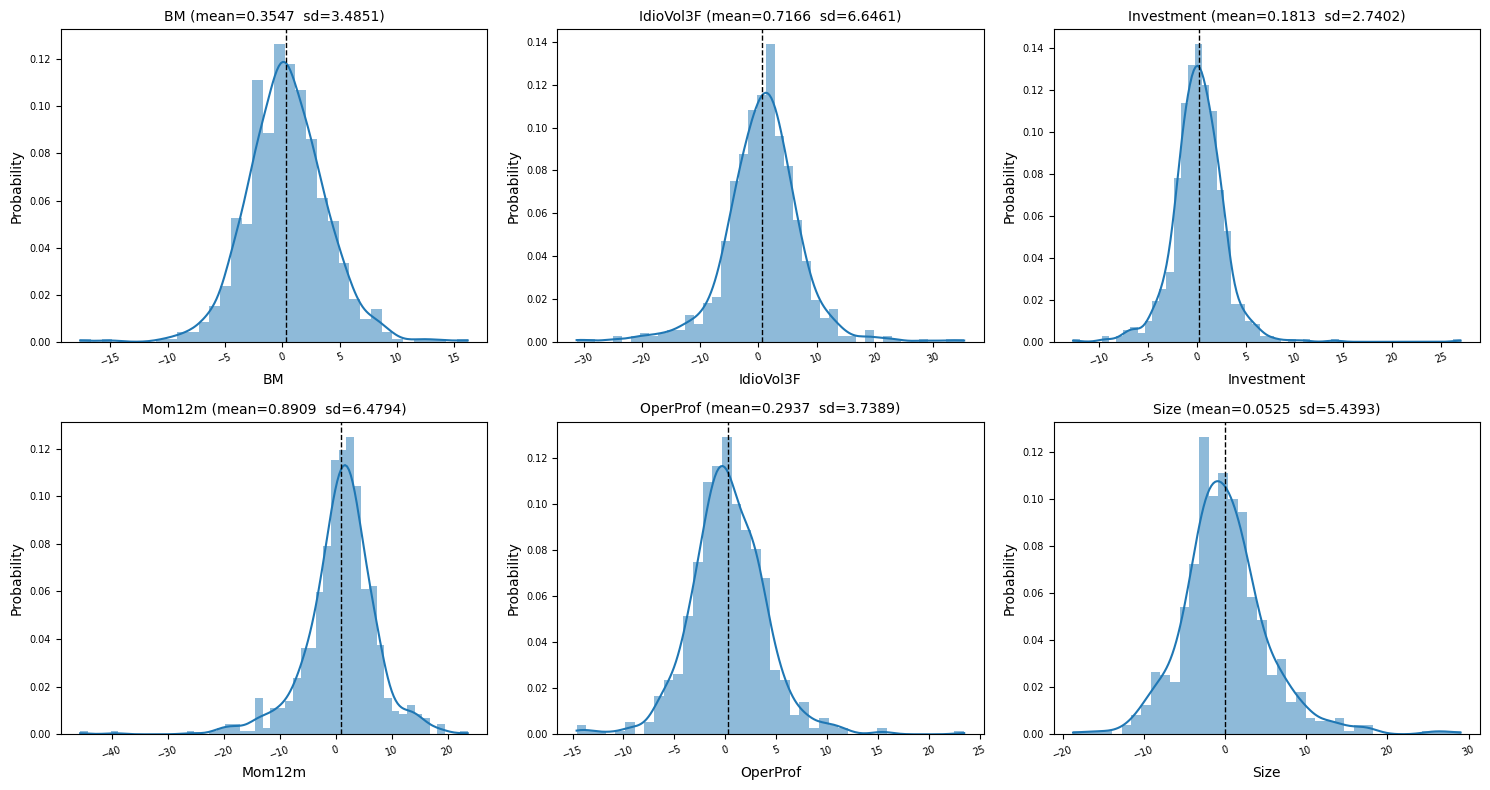

In [15]:
# plotting combined grid: histograms + KDE line for all factors monthly returns series
cols = osap_factor_returns.columns.tolist()
n, ncols = len(cols), 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = osap_factor_returns[col]
    if len(data) == 0:
        ax.set_visible(False)
        continue
    sns.histplot(data, kde=True, ax=ax, stat="probability", edgecolor=None)
    ax.set_title(f"{col} (mean={data.mean():.4f}  sd={data.std():.4f})", fontsize=10)
    ax.axvline(data.mean(), color='k', linestyle='--', linewidth=1)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(labelsize=7)

# turning off any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
fig.savefig(f"{outputs_dir}/eda/1. summary_stats_distributions/osap_factor_returns_distributions_grid.png", dpi=300, bbox_inches='tight')
plt.show()

The Open Asset Pricing long–short factor returns display reasonable coverage (720 monthly observations) and meaningful cross-factor dispersion. Average monthly returns vary across factors, with $Mom12m$ and $OperProf$ showing higher means, while $Size$ and $Investment$ are smaller on average. Standard deviations differ substantially ($IdioVol3F$ and $Mom12m$ are the most volatile), and skew/kurtosis indicate mild asymmetry and fat tails for several series — a reminder to use robust covariance estimation and to test downside-aware utilities later.

From the distribution plots, the factor series are roughly unimodal but not perfectly Gaussian: many show heavier tails and occasional extreme values, especially $momentum$ and $idiosyncratic-vol$. This motivates 
- (a) using quantile-based discretization for BN structure learning,
- (b) preferring shrinkage or EWMA covariances for the decision node, and 
- (c) including regime-aware checks (HMM / yearwise analysis) because factor relationships may change over time. 

Next we’ll quantify pairwise relationships (Pearson and Spearman) and study how correlations evolve year-by-year to guide DBN / dynamic-BN choices.

### **Step 1.2- Correlation Analysis**

In [16]:
os.makedirs(f"{outputs_dir}/eda/2. correlation_stats", exist_ok=True)

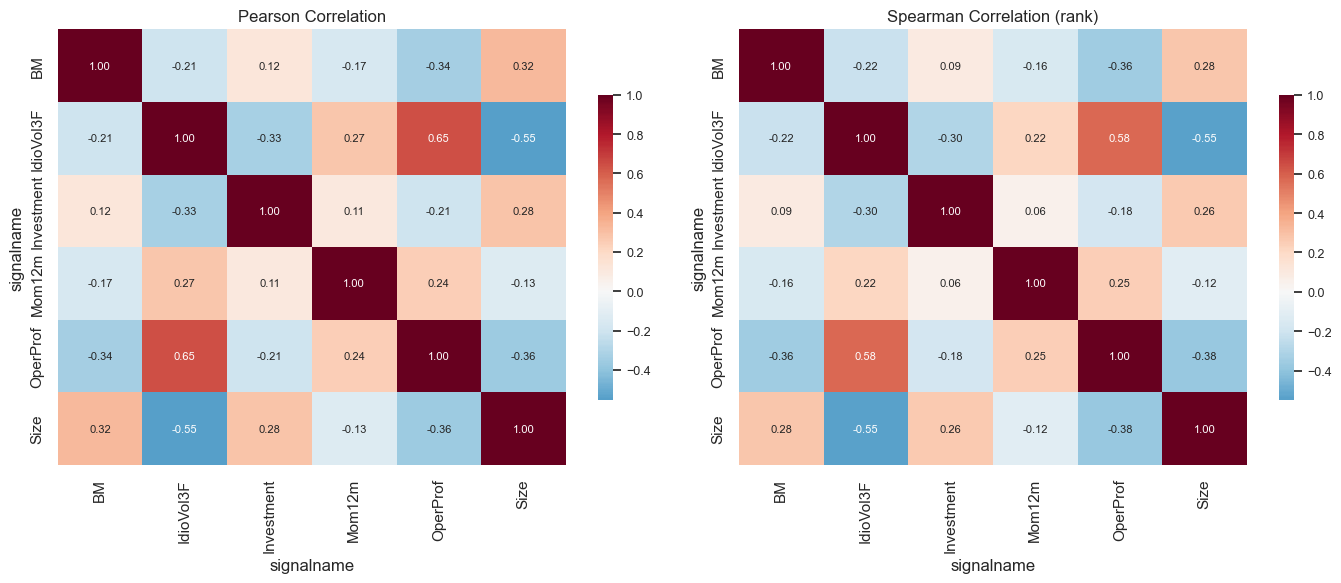

In [17]:
# computing spearman and pearson correlations to understand both linear and monotonic relationship between factors
pearson = osap_factor_returns.corr(method='pearson')
spearman = osap_factor_returns.corr(method='spearman')

# pretty-plotting
sns.set(style="white")
fig, ax = plt.subplots(1,2, figsize=(14,6))
sns.heatmap(pearson, annot=True,  annot_kws={"size": 8}, fmt=".2f", cmap='RdBu_r', center=0, ax=ax[0], cbar_kws={'shrink':0.7})
ax[0].set_title("Pearson Correlation")
sns.heatmap(spearman, annot=True,  annot_kws={"size": 8}, fmt=".2f", cmap='RdBu_r', center=0, ax=ax[1], cbar_kws={'shrink':0.7})
ax[1].set_title("Spearman Correlation (rank)")
# Set colorbar tick label size
ax[0].collections[0].colorbar.ax.tick_params(labelsize=9)
ax[1].collections[0].colorbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [18]:
# top pairs by absolute correlation (pearson)
pairs = (pearson.abs().where(np.triu(np.ones(pearson.shape), k=1).astype(bool))
         .stack().sort_values(ascending=False))
print("\nTop absolute Pearson correlations (factor pairs):")
display(pairs.head(10))


Top absolute Pearson correlations (factor pairs):


signalname  signalname
IdioVol3F   OperProf      0.646052
            Size          0.550902
OperProf    Size          0.357529
BM          OperProf      0.337683
IdioVol3F   Investment    0.328715
BM          Size          0.324749
Investment  Size          0.280103
IdioVol3F   Mom12m        0.274464
Mom12m      OperProf      0.242853
BM          IdioVol3F     0.209238
dtype: float64

In [19]:
# save correlation tables and heatmaps
pearson.to_csv(f"{outputs_dir}/eda/2. correlation_stats/osap_correlation_pearson.csv")
spearman.to_csv(f"{outputs_dir}/eda/2. correlation_stats/osap_correlation_spearman.csv")
fig.savefig(f"{outputs_dir}/eda/2. correlation_stats/osap_correlation_heatmaps.png", dpi=300, bbox_inches='tight')

The overall Pearson and Spearman heatmaps show generally moderate inter-factor relationships: most pairwise correlations lie in the low-to-mid range rather than being near $±1$. The strongest linear association is $IdioVol3F – OperProf (≈ 0.65)$, followed by $IdioVol3F – Size (≈ 0.55)$ and $OperProf – Size (≈ 0.36)$; other notable pairs include $BM – OperProf (~0.34)$ and $BM – Size (~0.32)$. Spearman (rank) correlations are directionally consistent with Pearson but slightly different in magnitude for some pairs (e.g., Momentum and idio-vol show a stronger rank relationship), which indicates that some dependencies are partly nonlinear or influenced by outliers. In short: the six chosen OpenAP factors are not collinear, but a few strong pairwise relationships (especially involving IdioVol3F, OperProf and Size) warrant special attention during BN structure selection and covariance estimation.

In [20]:
# Yearwise Correlations and Stability of factors

# prepare year index
osap_factors_yearly = osap_factor_returns.copy()
osap_factors_yearly['year'] = osap_factors_yearly.index.year

years = sorted(osap_factors_yearly['year'].unique())
n_years = len(years)
print("Years available:", years[0], "to", years[-1], f"({n_years} years)")

Years available: 1964 to 2023 (60 years)


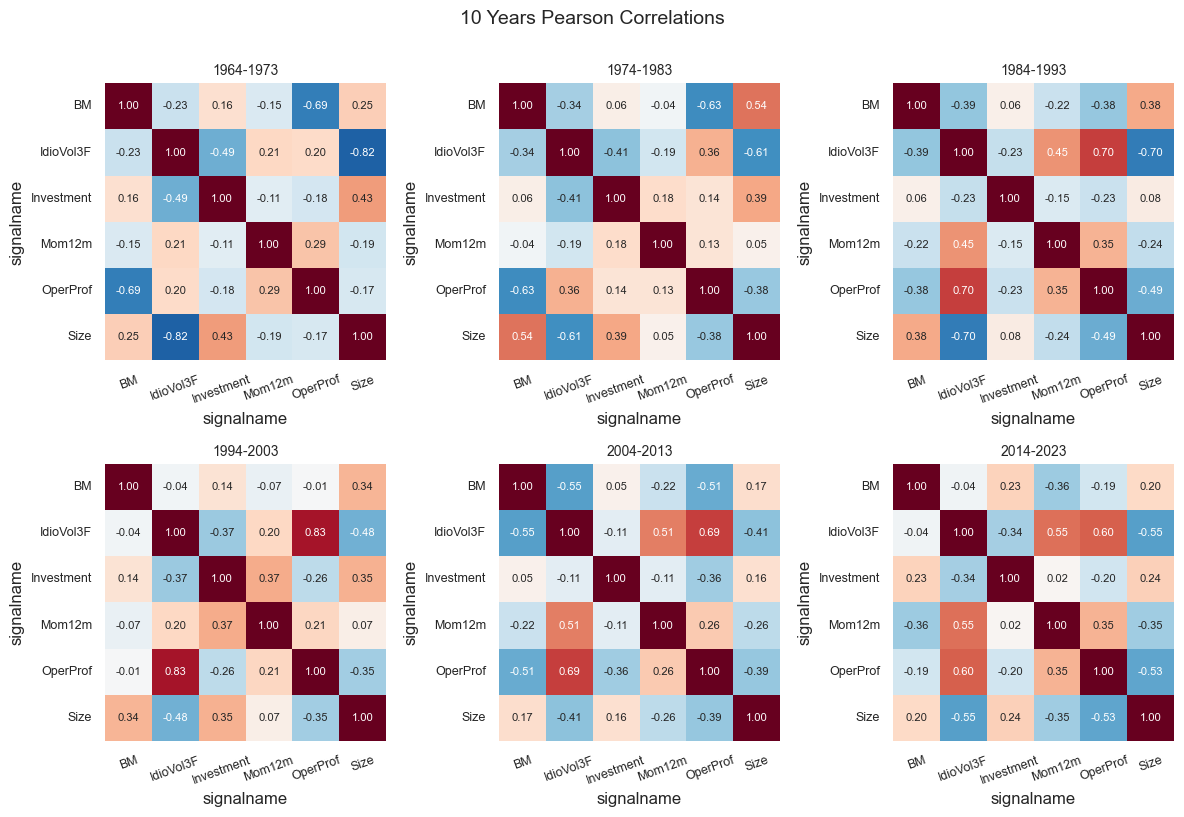

In [21]:
# computing period wise (10-Years Period) correlation matrices and heatmaps
year_corrs = {}
max_cols = osap_factor_returns.shape[1]
ncols = 3
nrows = math.ceil(n_years / ncols)
figsize = (4*ncols, 4*nrows)

fig = plt.figure(figsize=figsize)
for i, y in enumerate(range(years[0], years[-1]+1, 10)):
    sub = fig.add_subplot(nrows, ncols, i+1)
    dfy = osap_factors_yearly[osap_factors_yearly['year'].between(y, y+9)]
    dfy = dfy.drop(columns='year')
    yc = dfy.corr()
    year_corrs[f"{y}-{y+9}"] = yc
    sns.heatmap(yc, vmin=-1, vmax=1, center=0, fmt=".2f", cmap='RdBu_r', annot=True,  annot_kws={"size": 8}, cbar=False, ax=sub, cbar_kws={"labelsize": 9})
    sub.set_title(f"{y}-{y+9}", fontsize=10)
    
    # changing the ticks font for both y and x axis
    sub.tick_params(axis='x', rotation=20, labelsize=9)
    sub.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle("10 Years Pearson Correlations", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# saving the figure
fig.savefig(f"{outputs_dir}/eda/2. correlation_stats/osap_yearwise_correlation_multiples.png", dpi=250, bbox_inches='tight')

The decade panels (1964–1973, 1974–1983, …, 2014–2023) reveal clear evolution in factor relationships. Mean absolute correlation per decade ranges from $≈0.27 (1994–2003)$ up to $≈0.34 (1984–1993)$, indicating periods of higher coupling and calmer decades with more independence. Visual inspection of the heatmaps shows the 1984–1993 and 2004–2013 blocks with relatively stronger co-movement among factors, whereas the 1994–2003 decade shows weaker average coupling. This multi-decade perspective suggests structural shifts in how style exposures interact (likely tied to macro/regime episodes), which argues for incorporating time-varying or regime-aware elements when learning BN structure (for example, re-learning structure on multi-year windows or using a DBN).

In [22]:
# stability metrics and top changing pairs between decades

# 1) Mean absolute correlation per period
stability_list = []
for period, mat in year_corrs.items():

    vals = mat.values
    iu = np.triu_indices_from(vals, k=1)
    upper = vals[iu]
    mean_abs = np.nanmean(np.abs(upper))
    mean_signed = np.nanmean(upper)
    stability_list.append({
        'period': period,
        'mean_abs_corr': mean_abs,
        'mean_signed_corr': mean_signed,
        'n_pairs': len(upper)
    })

stability_df = pd.DataFrame(stability_list).set_index('period')
stability_df.to_csv(f"{outputs_dir}/eda/2. correlation_stats/osap_decade_mean_abs_correlation_summary.csv")
display(stability_df)

,mean_abs_corr,mean_signed_corr,n_pairs
period,,,
1964-1973,0.303529,-0.100172,15
1974-1983,0.297542,-0.049655,15
1984-1993,0.336634,-0.067925,15
1994-2003,0.273030,0.062519,15
2004-2013,0.317209,-0.070319,15
2014-2023,0.316574,-0.025663,15


In [23]:
# 2) top changing pairs between consecutive periods
# sort periods in chronological order based on string like "1963-1972" -> use start year
def period_start(p):
    return int(p.split('-')[0])

period_keys = sorted(list(year_corrs.keys()), key=period_start)
top_movers_records = []

for i in range(1, len(period_keys)):
    p0 = period_keys[i-1]
    p1 = period_keys[i]
    C0 = year_corrs[p0].reindex(index=year_corrs[p0].index, columns=year_corrs[p0].columns)
    C1 = year_corrs[p1].reindex(index=year_corrs[p1].index, columns=year_corrs[p1].columns)

    # ensure same ordering of rows/cols
    common_vars = [c for c in C0.columns if c in C1.columns]
    C0 = C0.loc[common_vars, common_vars]
    C1 = C1.loc[common_vars, common_vars]

    # compute abs change matrix and extract upper triangle
    diff = (C1 - C0).abs()
    dif_vals = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool)).stack()
    dif_vals = dif_vals.dropna().sort_values(ascending=False)

    # top 10 movers for this pair of decades
    top_n = 10 if len(dif_vals) >= 10 else len(dif_vals)
    top = dif_vals.head(top_n)

    for pair, val in top.items():
        v1, v2 = pair
        top_movers_records.append({
            'from_period': p0,
            'to_period': p1,
            'pair': f"{v1} - {v2}",
            'abs_corr_change': val
        })

# convert to DataFrame and save
top_movers_df = pd.DataFrame(top_movers_records)
top_movers_df.to_csv(f"{outputs_dir}/eda/2. correlation_stats/osap_decade_top_corr_pair_changes.csv", index=False)
display(top_movers_df)

,from_period,to_period,pair,abs_corr_change
0,1964-1973,1974-1983,IdioVol3F - Mom12m,0.398607
1,1964-1973,1974-1983,Investment - OperProf,0.321556
2,1964-1973,1974-1983,Investment - Mom12m,0.297793
3,1964-1973,1974-1983,BM - Size,0.296731
4,1964-1973,1974-1983,Mom12m - Size,0.242758
5,1964-1973,1974-1983,OperProf - Size,0.212854
6,1964-1973,1974-1983,IdioVol3F - Size,0.202619
7,1964-1973,1974-1983,IdioVol3F - OperProf,0.160841
8,1964-1973,1974-1983,Mom12m - OperProf,0.151141
9,1964-1973,1974-1983,BM - IdioVol3F,0.116096


In [24]:
# 3) printing a concise summary for the most recent decade transition
if len(period_keys) >= 2:
    last_from, last_to = period_keys[-2], period_keys[-1]
    print(f"\nTop movers from {last_from} -> {last_to}:")
    display(top_movers_df[top_movers_df['from_period']==last_from].head(10))


Top movers from 2004-2013 -> 2014-2023:


,from_period,to_period,pair,abs_corr_change
40,2004-2013,2014-2023,BM - IdioVol3F,0.506191
41,2004-2013,2014-2023,BM - OperProf,0.317131
42,2004-2013,2014-2023,IdioVol3F - Investment,0.237450
43,2004-2013,2014-2023,BM - Investment,0.180870
44,2004-2013,2014-2023,Investment - OperProf,0.155963
45,2004-2013,2014-2023,OperProf - Size,0.143184
46,2004-2013,2014-2023,BM - Mom12m,0.138596
47,2004-2013,2014-2023,IdioVol3F - Size,0.136719
48,2004-2013,2014-2023,Investment - Mom12m,0.129584
49,2004-2013,2014-2023,IdioVol3F - OperProf,0.094490


The stability summary shows modest but meaningful shifts across decades; mean absolute correlation moves between $~0.273$ and $~0.337$. The largest recent mover is the transition $2004–2013 → 2014–2023$, where the top absolute change is $BM – IdioVol3F (Δ ≈ 0.506)$ — a very large change indicating that the relationship between value and idiosyncratic volatility flipped materially in the most recent decade. Other notable movers for that transition include $BM – OperProf (Δ ≈ 0.317)$ and $IdioVol3F – Investment (Δ ≈ 0.237)$. Practically, this implies we should 
- (a) consider retraining or re-estimating BN structure on a decadal cadence as a baseline, and 
- (b) trigger ad-hoc re-learning when mean-abs-correlation spikes (e.g., the ~0.34 decade) or when a large pairwise shift (like the 0.5 jump above) occurs — those events signal structural regime change and could invalidate a static causal graph.

### **Step 1.3- Time Series Plots**

In [25]:
os.makedirs(f"{outputs_dir}/eda/3. time_series_stats/", exist_ok=True)

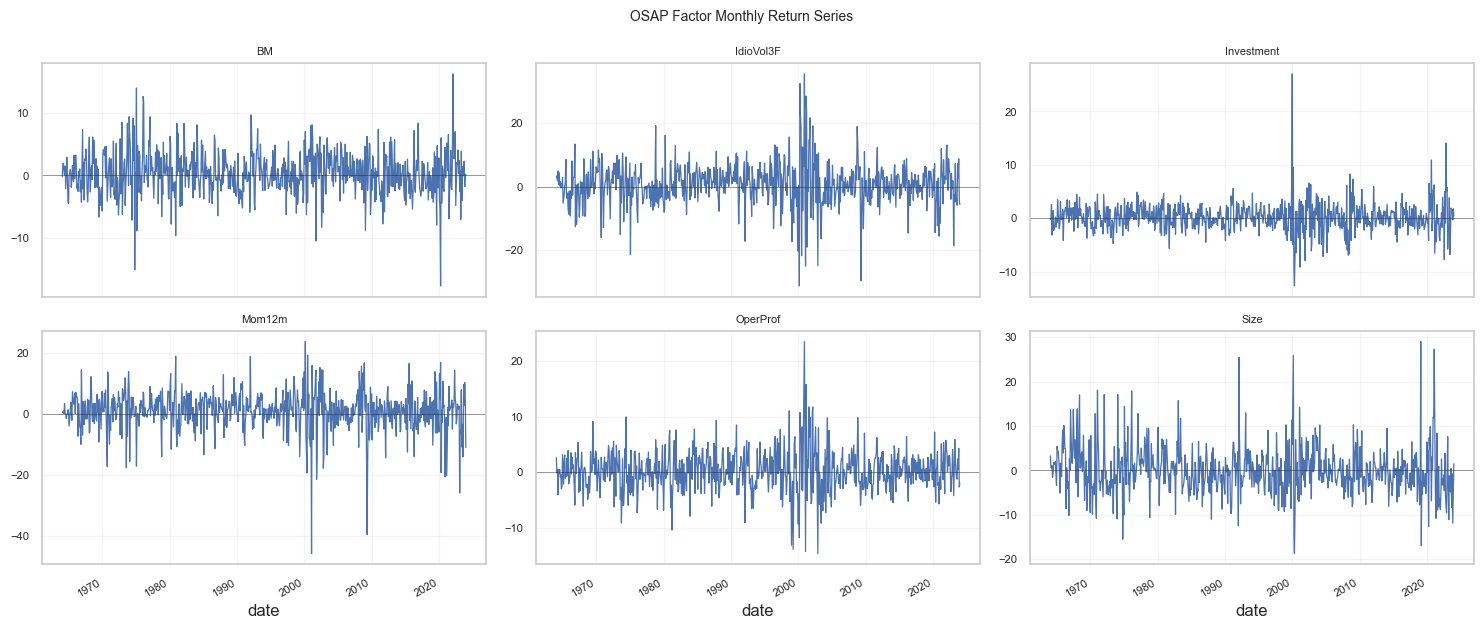

In [ ]:
# reading the osap factor returns data
osap_factor_returns = pd.read_csv(f"{inputs_dir}/clean/osap_factor_returns.csv", index_col=0, parse_dates=True)

# 1. monthly return series grid plot
n = osap_factor_returns.shape[1]
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), sharex=True)
axes = axes.flatten()
plt.suptitle("OSAP Factor Monthly Return Series", fontsize=10)
for i, col in enumerate(osap_factor_returns.columns):
    ax = axes[i]
    osap_factor_returns[col].plot(ax=ax, lw=0.9, fontsize=8)
    ax.set_title(col, fontsize=8)
    ax.axhline(0, color='k', linewidth=0.5, alpha=0.6)
    ax.grid(alpha=0.2)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()

fig.savefig(f"{outputs_dir}/eda/3. time_series_stats/osap_monthly_series_grid.png", dpi=250, bbox_inches='tight')
plt.show()

The monthly long–short factor returns show frequent fluctuations around zero, with evident volatility clustering.

- **Momentum (Mom12m)** and **IdioVol3F** exhibit the highest variability, frequently experiencing large positive and negative swings, consistent with their sensitivity to market cycles and volatility regimes.
- **Investment, Size, and Book-to-Market (BM)** remain relatively stable, with narrower amplitude and fewer extreme events.
- Occasional spikes correspond to global crises (e.g., 2000 dot-com, 2008 GFC, 2020 COVID).

This variability underlines the need for robust volatility modeling and regime awareness in both BN learning and Influence Diagram optimization.

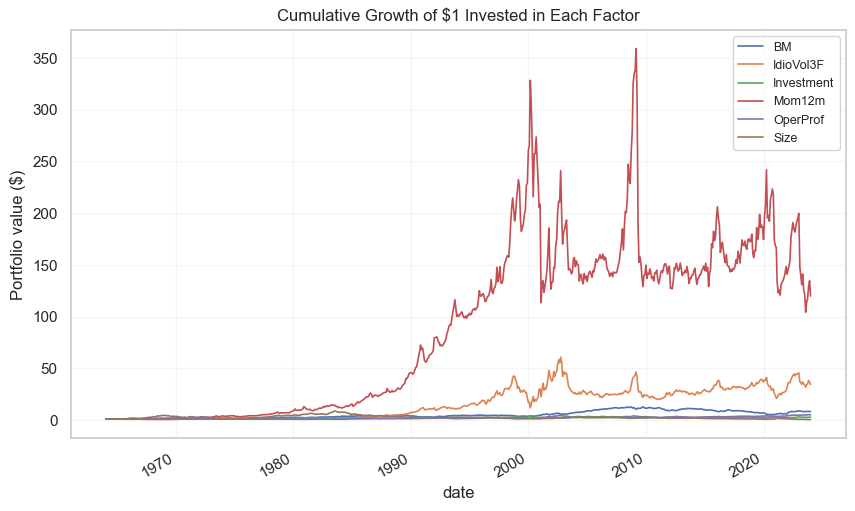

In [ ]:
# 2. cumulative returns (growth of $1)
cum = (1 + osap_factor_returns/100).cumprod()
fig, ax = plt.subplots(figsize=(10,6))
cum.plot(ax=ax, lw=1.2)
ax.set_title("Cumulative Growth of $1 Invested in Each Factor")
ax.set_ylabel("Portfolio value ($)")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.2)

fig.savefig(f"{outputs_dir}/eda/3. time_series_stats/osap_cumulative_returns_grid.png", dpi=250, bbox_inches='tight')
plt.show()

Cumulative return paths highlight clear performance dispersion across factors.

- **Momentum (Mom12m)** dominates long-term compounding, reaching values above $300, while most others remain below $20.
- **IdioVol3F** and **Investment** show intermediate growth with sharp cyclical drawdowns.
- **BM, OperProf, and Size** are flatter, indicating mean-reverting or defensive behavior.

The stark divergence suggests each factor represents a distinct return driver, supporting their inclusion as separate nodes in the causal network and enabling diversified utility in the Influence Diagram.

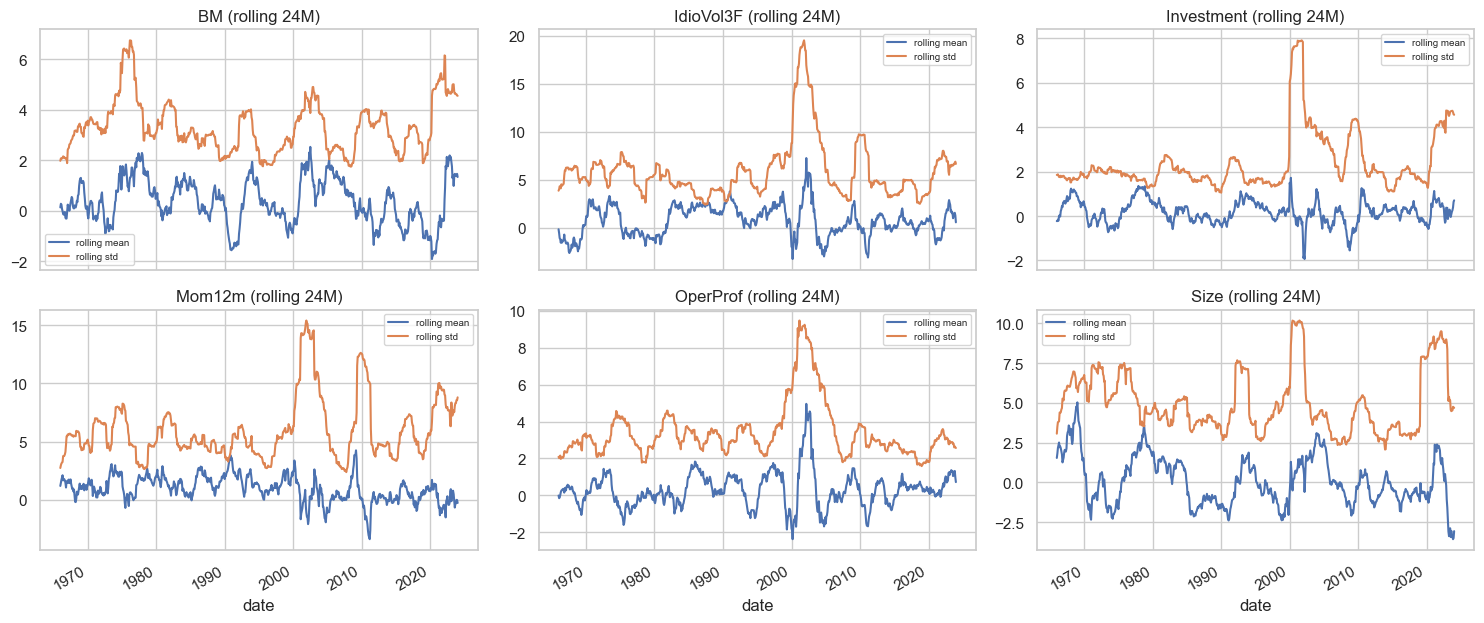

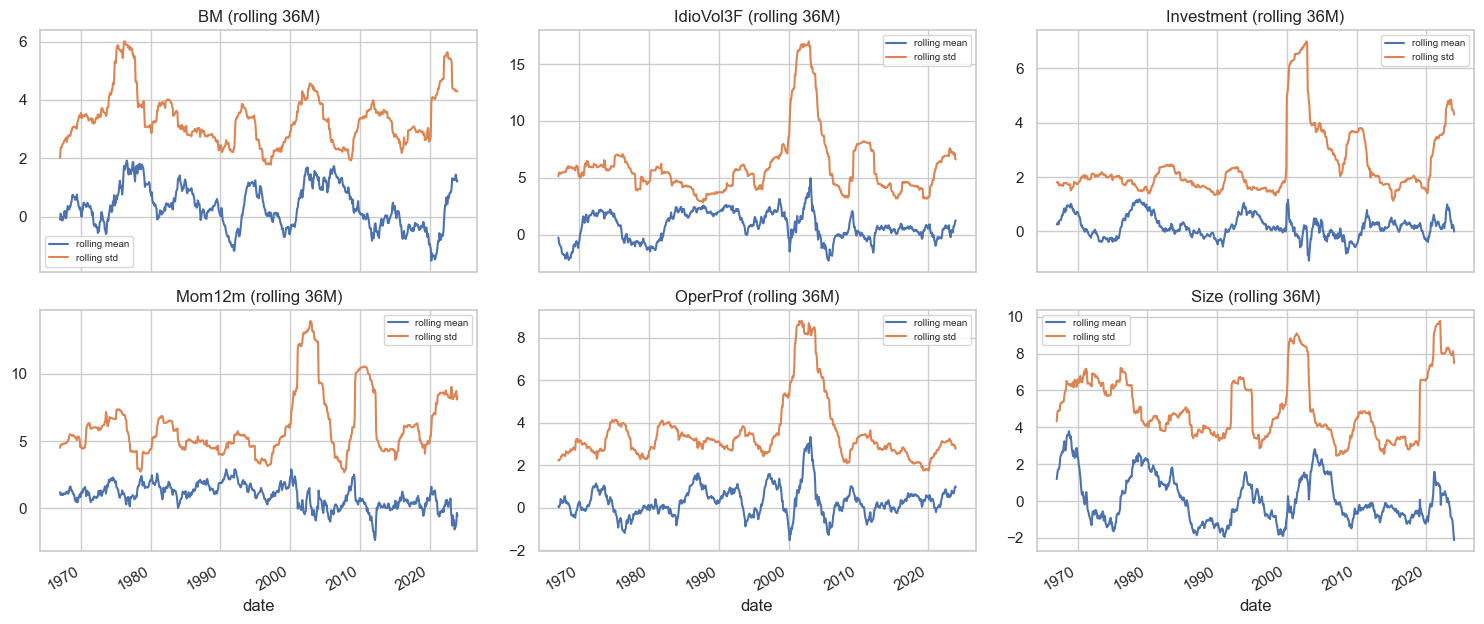

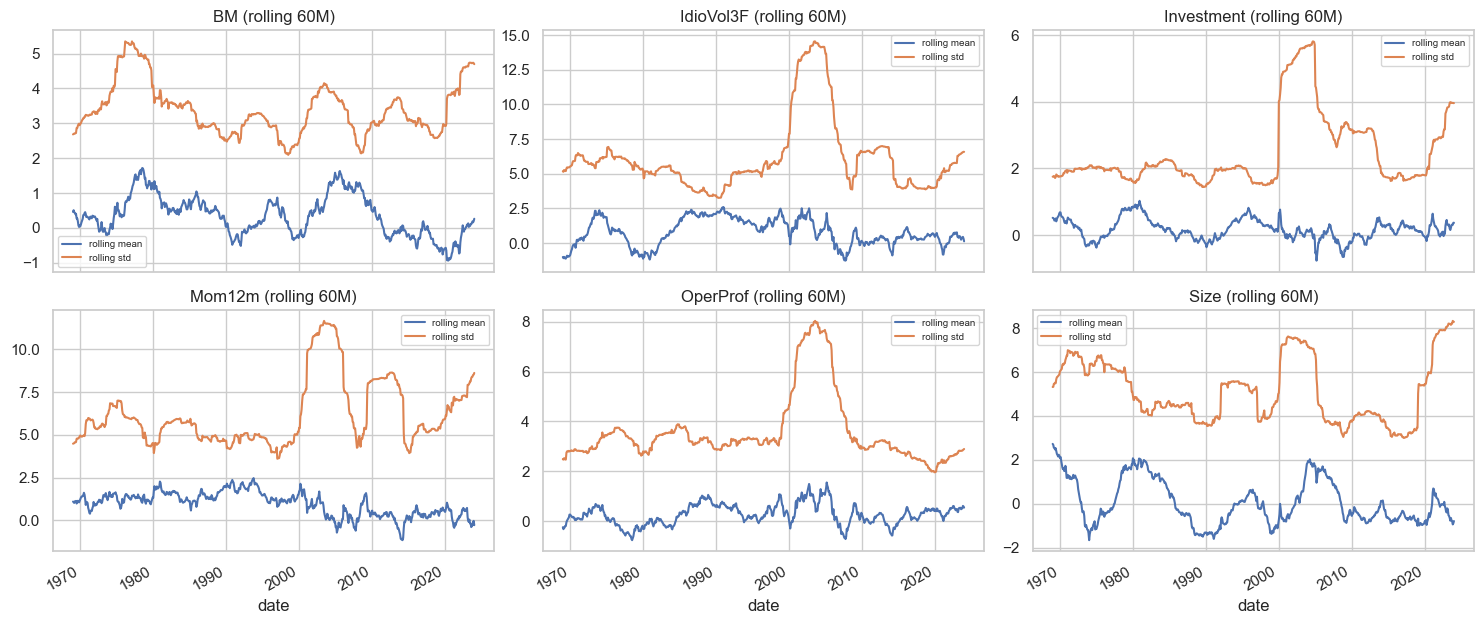

In [32]:
# 3. Rolling stats: 24 months, 36 months, and 60 months for sensitivity
for window in [24, 36, 60]:
    roll_mean = osap_factor_returns.rolling(window=window).mean()
    roll_std = osap_factor_returns.rolling(window=window).std()
    
    # saving the rolling average and standard deviations summaries
    roll_mean.to_csv(f"{outputs_dir}/eda/3. time_series_stats/osap_rolling_mean_{window}m.csv")
    roll_std.to_csv(f"{outputs_dir}/eda/3. time_series_stats/osap_rolling_std_{window}m.csv")
    
    # plotting the rolling mean and std grid
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), sharex=True)
    axes = axes.flatten()
    for i, col in enumerate(osap_factor_returns.columns):
        ax = axes[i]
        roll_mean[col].plot(ax=ax, label='rolling mean')
        roll_std[col].plot(ax=ax, label='rolling std')
        ax.set_title(f"{col} (rolling {window}M)")
        ax.legend(fontsize=7)
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    
    fig.savefig(f"{outputs_dir}/eda/3. time_series_stats/osap_rolling_mean_std_{window}m.png", dpi=250, bbox_inches='tight')
    plt.show()

Rolling statistics reveal persistent but time-varying volatility regimes.

- Across all horizons, **Mom12m** and **IdioVol3F** consistently show the highest rolling standard deviations, peaking around **2000–2010** and again during **2020**, confirming episodic market stress.
- **Investment, BM, and OperProf** maintain lower volatility with relatively stable rolling means, suggesting they capture slow-moving fundamentals.
- The repeating volatility cycles across window lengths (24M–60M) imply a multi-year persistence of regimes, motivating dynamic BNs or hidden-state nodes to capture structural shifts.

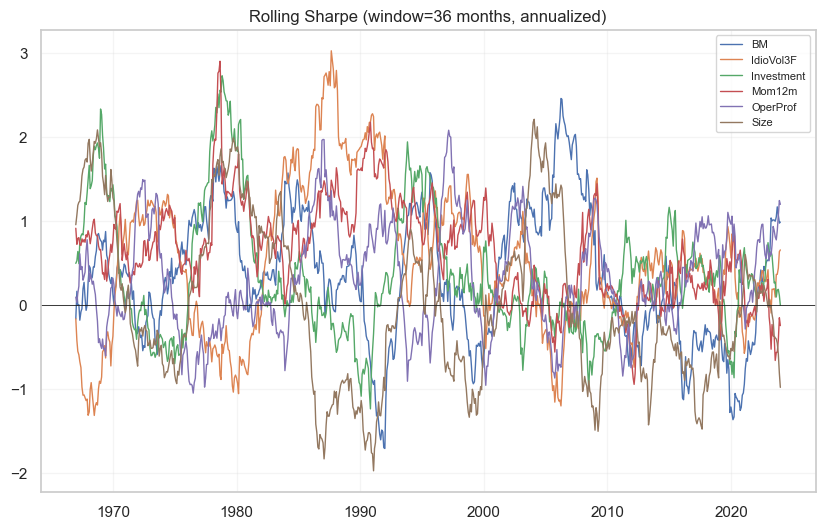

In [33]:
# 4. Rolling Sharpe for 36 months - annualized assuming monthly returns
win = 36
roll_mean = osap_factor_returns.rolling(window=win).mean()
roll_std = osap_factor_returns.rolling(window=win).std()
roll_sharpe = (roll_mean * 12) / (roll_std * np.sqrt(12))   # annualized mean / annualized std
roll_sharpe.to_csv(f"{outputs_dir}/eda/3. time_series_stats/osap_rolling_sharpe_{win}m.csv")

fig, ax = plt.subplots(figsize=(10,6))
for col in osap_factor_returns.columns:
    ax.plot(roll_sharpe.index, roll_sharpe[col], label=col, lw=1)
ax.set_title(f"Rolling Sharpe (window={win} months, annualized)")
ax.axhline(0, color='k', lw=0.6)
ax.legend(loc='best', fontsize=8)
ax.grid(alpha=0.2)

fig.savefig(f"{outputs_dir}/eda/3. time_series_stats/osap_rolling_sharpe_{win}m.png", dpi=250, bbox_inches='tight')
plt.show()

Rolling Sharpe trajectories oscillate widely across decades, with all factors occasionally dipping below zero.

- **OperProf** and **BM** tend to sustain positive Sharpe ratios longer, aligning with profitability and value persistence.
- **Momentum** produces the highest peaks but also deep troughs, emphasizing regime dependence.
- **IdioVol3F** exhibits alternating phases of out- and under-performance, often mirroring volatility cycles.

These patterns reinforce that factor risk-adjusted returns are non-stationary, requiring time-adaptive decision utilities within the Influence Diagram to maintain robustness.

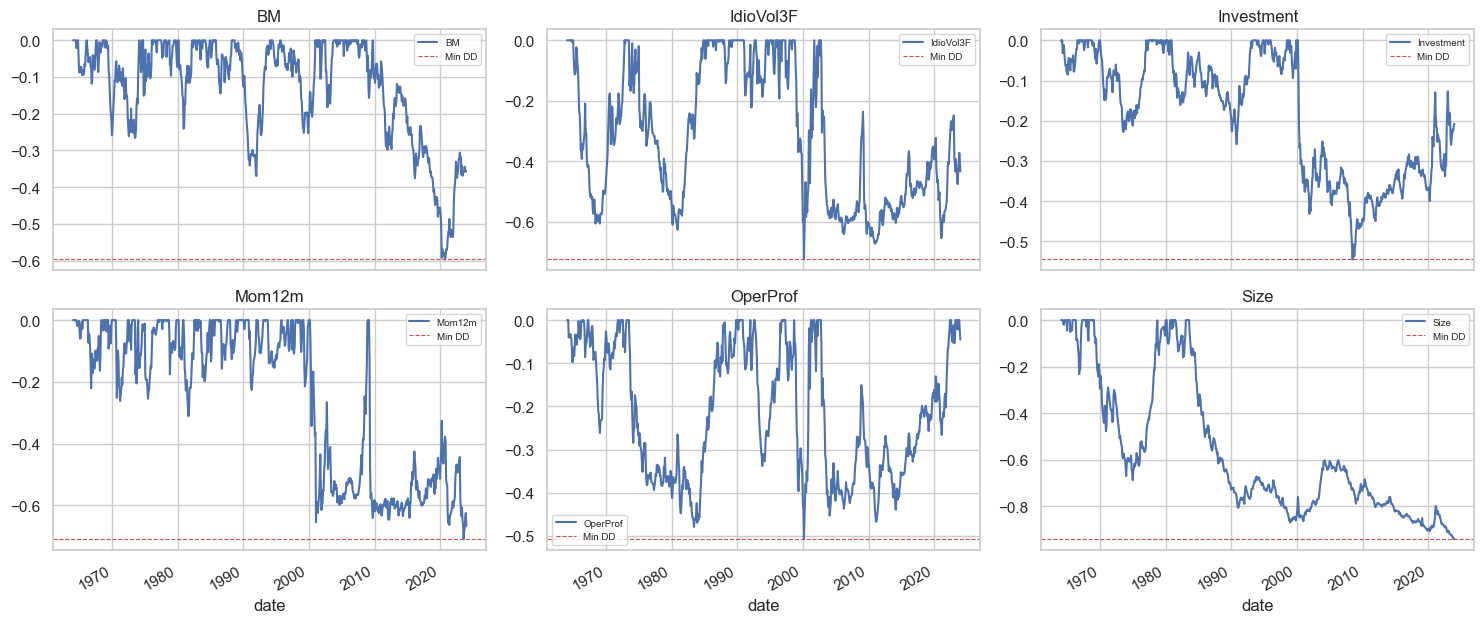

In [37]:
# 5. Drawdowns
osap_dd = (osap_factor_returns/100).apply(compute_drawdown)
osap_dd.to_csv(f"{outputs_dir}/eda/3. time_series_stats/osap_drawdowns.csv")

# plotting maximum drawdown timeline (small multiples)
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), sharex=True)
axes = axes.flatten()
for i, col in enumerate(osap_factor_returns.columns):
    ax = axes[i]
    osap_dd[col].plot(ax=ax)
    ax.set_title(col)
    ax.axhline(osap_dd[col].min(), color='r', linestyle='--', linewidth=0.8, label='Min DD')
    ax.legend(fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis('off')
plt.tight_layout()

fig.savefig(f"{outputs_dir}/eda/3. time_series_stats/osap_drawdowns.png", dpi=250, bbox_inches='tight')
plt.show()

The drawdown series show realistic depths and timing. 
- Some factors (notably **Size**) exhibit the deepest troughs — approaching very large losses in stress episodes.
- While Momentum (**Mom12m**) and **IdioVol3F** display frequent and sometimes very deep drawdowns as well (tens of percent up to $~-70%$ in extreme episodes). 
- **BM, Investment** and **OperProf** also suffer drawdowns during crisis windows but generally show smaller, shorter-lived troughs compared with the pro-cyclical factors. 

The above chart confirms that downside risk is highly factor-dependent and clustered in crisis periods.

### **Step 1.4- Autocorrelation**

In [39]:
os.makedirs(f"{outputs_dir}/eda/4. autocorrelation_stats/", exist_ok=True)

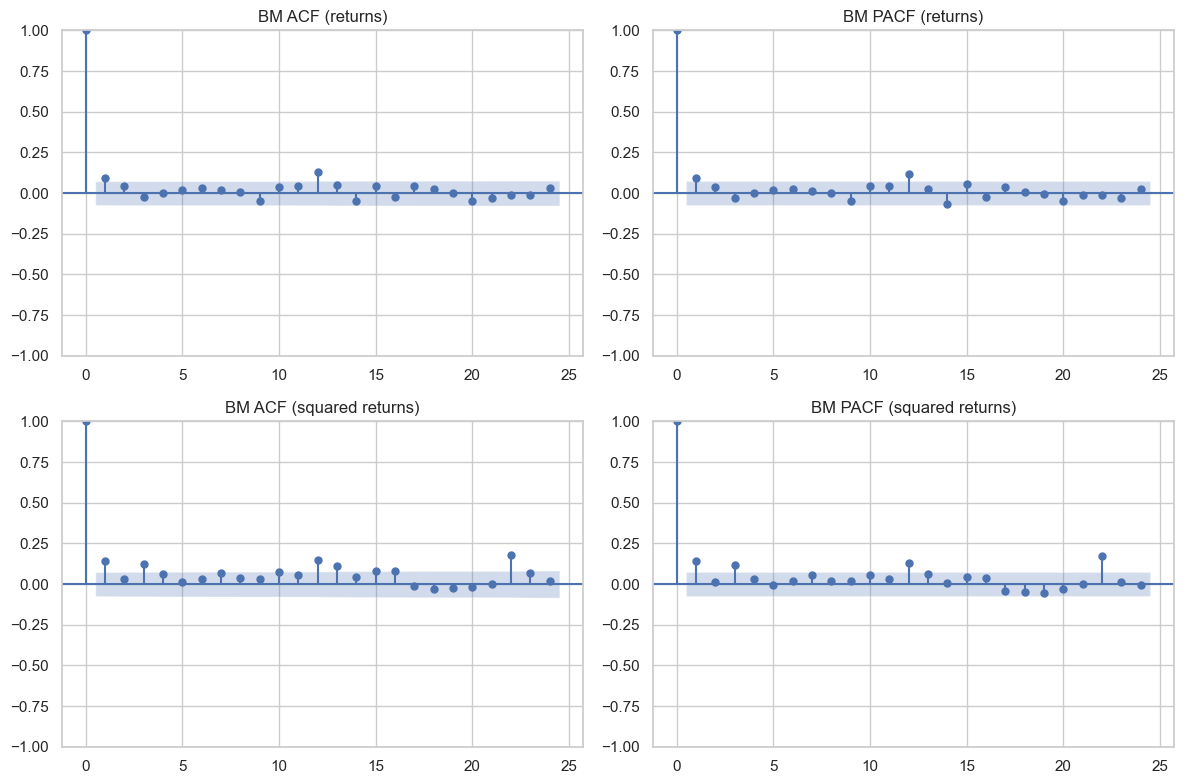

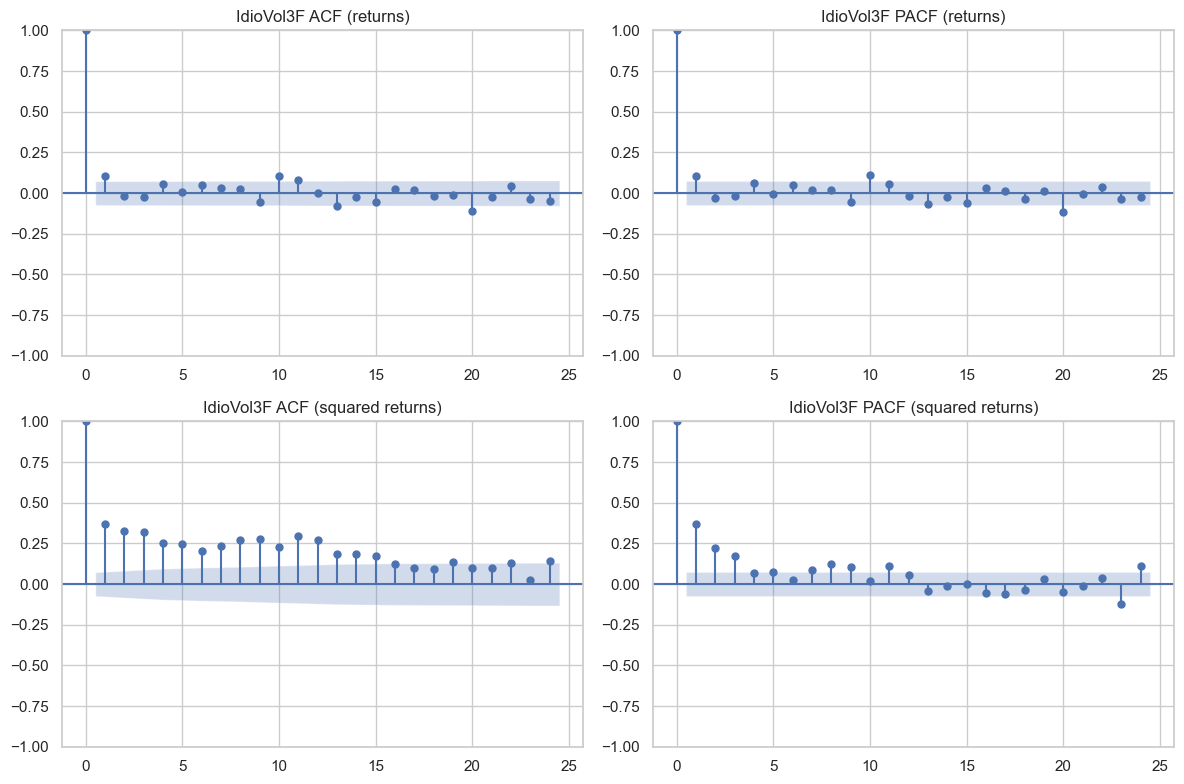

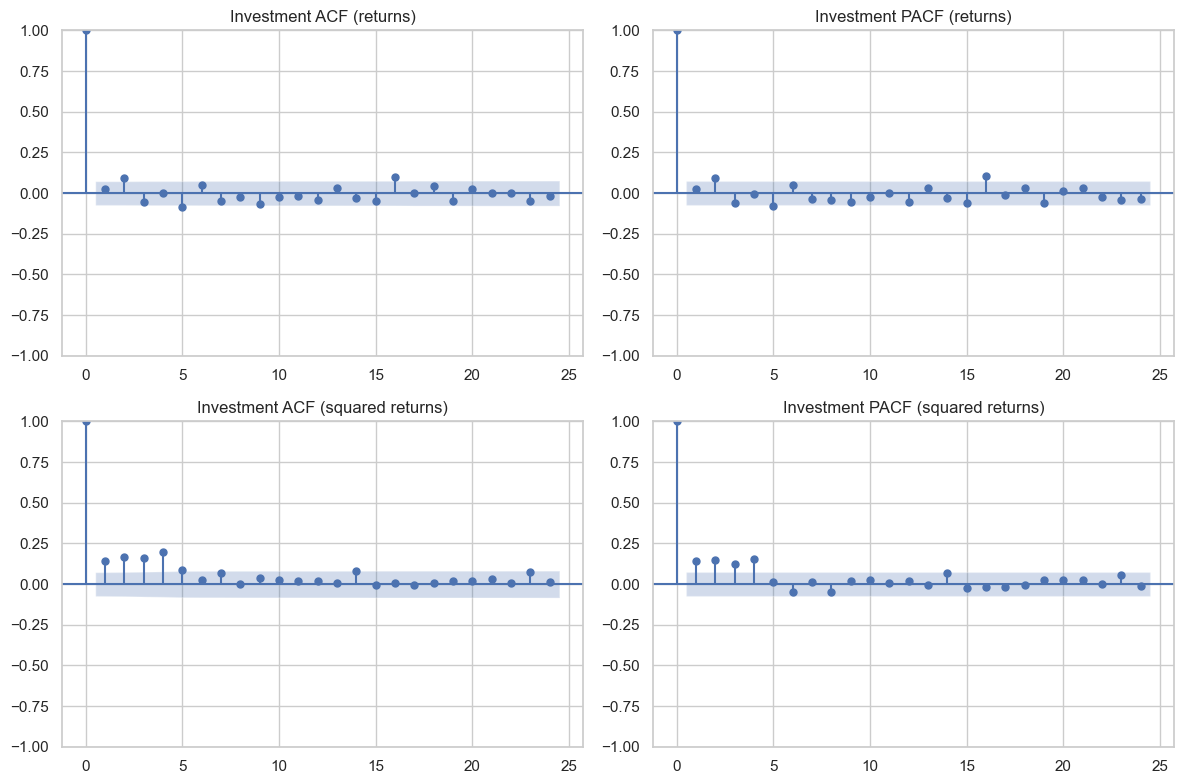

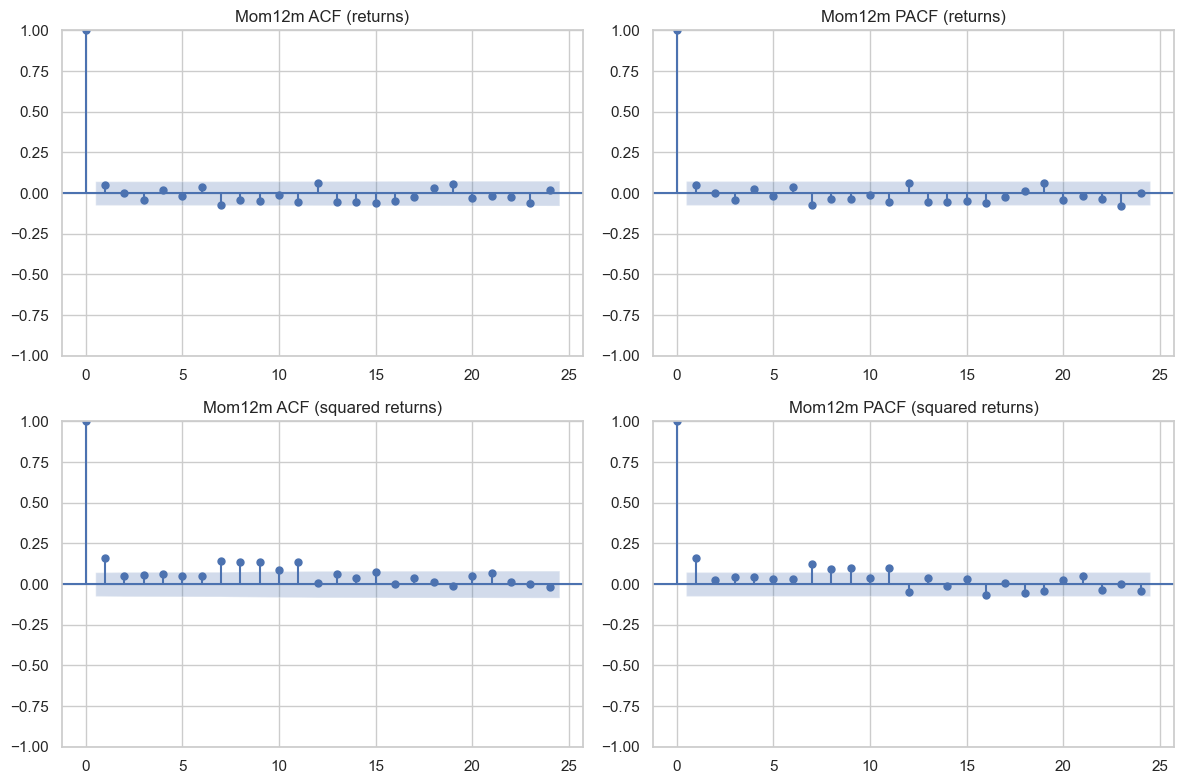

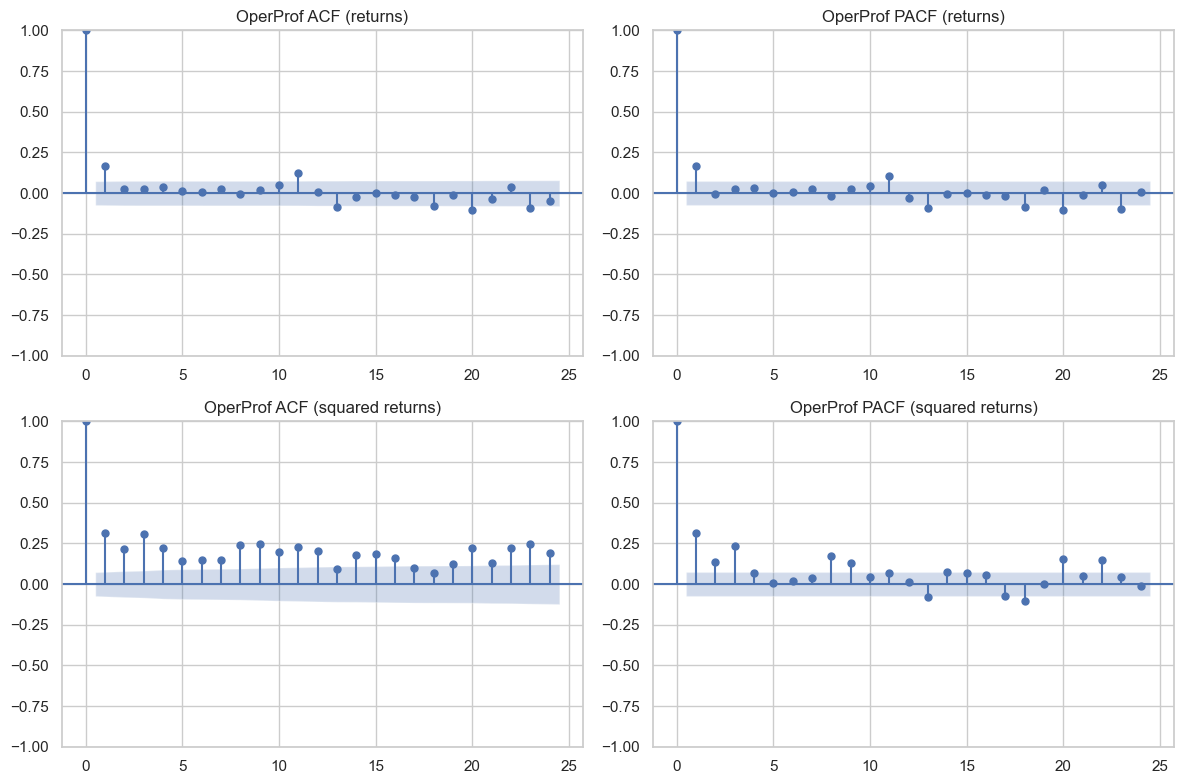

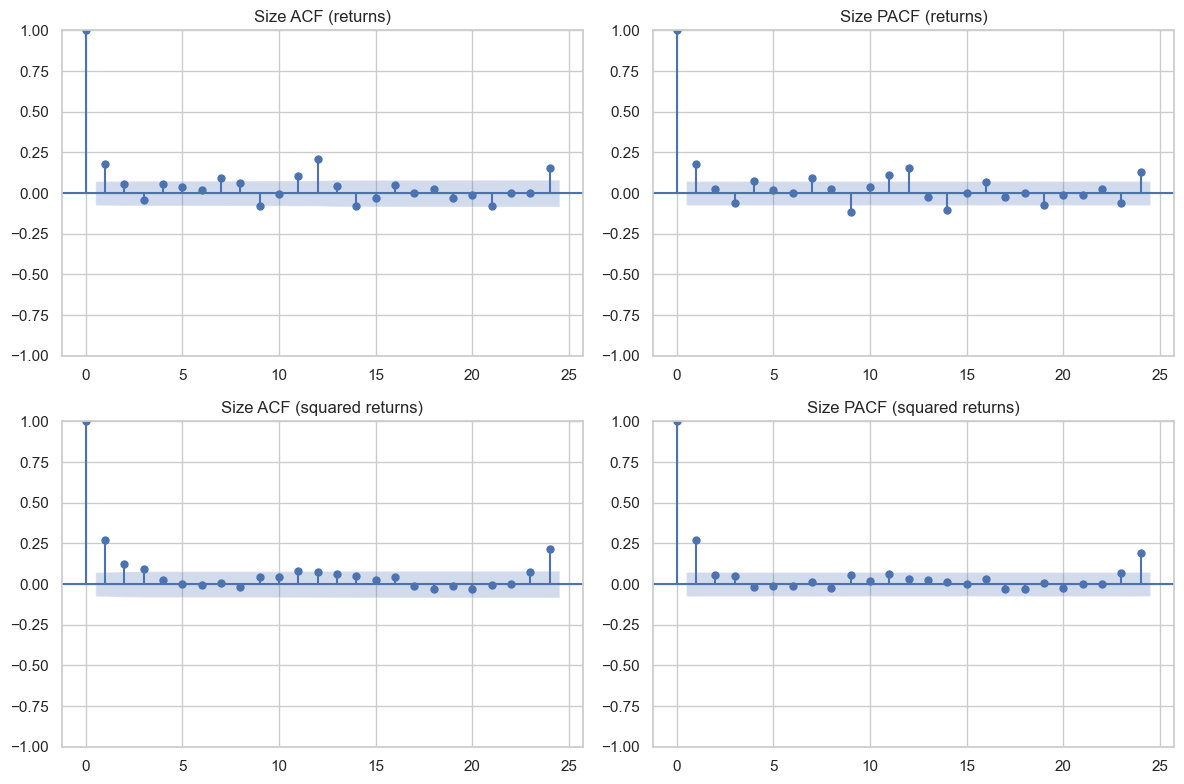


Ljung-Box p-values (per lag):


,1,6,12
BM,0.011535,0.173474,1.131997e-02
IdioVol3F,0.004721,0.046323,4.920293e-03
Investment,0.476366,0.011791,2.062226e-02
Mom12m,0.156350,0.549472,1.398055e-01
OperProf,0.000008,0.001157,3.672251e-04
Size,0.000001,0.000024,4.832647e-13


ARCH LM p-values (per lag):


,1,5,12
BM,1.406436e-04,1.653350e-04,4.086404e-05
IdioVol3F,5.598035e-23,1.091123e-30,2.532013e-31
Investment,1.701871e-04,8.551173e-11,3.015459e-08
Mom12m,1.867222e-05,5.297284e-04,1.971359e-07
OperProf,6.474879e-17,4.429926e-24,8.545536e-26
Size,5.275916e-13,1.029925e-10,1.572295e-08


GARCH(1,1) parameters:


,omega,alpha[1],beta[1]
BM,0.503947,0.100205,0.863091
IdioVol3F,2.181149,0.147603,0.802912
Investment,0.560914,0.243663,0.687594
Mom12m,1.591714,0.140892,0.833595
OperProf,0.479760,0.102626,0.859995
Size,8.393765,0.315958,0.424021


In [48]:
factors = osap_factor_returns/100.0
max_lags = 24  # up to 24 months (2 years)
lb_lags = [1,6,12]   # Ljung-Box lags to test
arch_lags = [1,5,12] # ARCH LM lags to test

# containers for summaries
ljung_summary = {}
arch_summary = {}
garch_summary = {}

# produce ACF/PACF plots for each factor
for col in factors.columns:
    s = factors[col].dropna()
    if s.empty: 
        continue

    # plot ACF/PACF of returns and squared returns
    fig, axes = plt.subplots(2,2, figsize=(12,8))
    plot_acf(s, lags=max_lags, ax=axes[0,0], title=f"{col} ACF (returns)")
    plot_pacf(s, lags=max_lags, ax=axes[0,1], title=f"{col} PACF (returns)")
    plot_acf(s**2, lags=max_lags, ax=axes[1,0], title=f"{col} ACF (squared returns)")
    plot_pacf(s**2, lags=max_lags, ax=axes[1,1], title=f"{col} PACF (squared returns)")
    plt.tight_layout()
    
    fig.savefig(f"{outputs_dir}/eda/4. autocorrelation_stats/osap_acf_pacf_{col}.png", dpi=200, bbox_inches='tight')
    plt.show()

    # Ljung-Box tests (returns)
    lb = acorr_ljungbox(s, lags=lb_lags, return_df=True)
    ljung_summary[col] = lb['lb_pvalue'].to_dict()  # p-values per lag

    # ARCH LM test on residuals (returns)
    arch_pvals = {}
    for L in arch_lags:
        arch_test = het_arch(s, maxlag=L)
        arch_pvals[L] = arch_test[1]
    arch_summary[col] = arch_pvals

    # GARCH(1,1) fit
    am = arch_model(s*100.0, vol='Garch', p=1, q=1, mean='Zero', dist='normal')  # scale by 100 for percent units in arch
    res = am.fit(disp='off')
    params = res.params.to_dict()
    garch_summary[col] = params

    # saving garch(1,1) summary
    open(f"{outputs_dir}/eda/4. autocorrelation_stats/osap_garch11_summary_{col}.txt", 'w').write(res.summary().as_text())
    
print("\nLjung-Box p-values (per lag):")
display(pd.DataFrame(ljung_summary).T)

print("ARCH LM p-values (per lag):")
display(pd.DataFrame(arch_summary).T)

print("GARCH(1,1) parameters:")
display(pd.DataFrame(garch_summary).T)

# saving Ljung-Box and ARCH results
pd.DataFrame(ljung_summary).T.to_csv(f"{outputs_dir}/eda/4. autocorrelation_stats/osap_ljungbox_pvalues.csv")
pd.DataFrame(arch_summary).T.to_csv(f"{outputs_dir}/eda/4. autocorrelation_stats/osap_arch_lm_pvalues.csv")
pd.DataFrame(garch_summary).T.to_csv(f"{outputs_dir}/eda/4. autocorrelation_stats/osap_garch11_params.csv")


> **Serial Dependence (ACF/PACF & Ljung–Box)**
- For BM, OperProf, and Size, the Ljung–Box p-values are highly significant at $lag 1 (< 0.01)$, confirming short-term autocorrelation.
- Investment and Mom12m show mild significance at short lags but fade by lag 12, indicating only weak serial persistence.
- IdioVol3F shows low p-values at lags 1–6, suggesting meaningful 1- to 3-month persistence—typical of volatility-based factors.
- The ACF/PACF plots reinforce this: almost all series exhibit small but non-zero correlation at lag 1, quickly dying out thereafter.

we can add a single-period lag node ($factor_{t-1}$) for BM, OperProf, Size, and possibly IdioVol3F when constructing the Dynamic BN. This allows temporal propagation of causal effects without over-parameterizing the network.

> **Volatility Clustering (ACF of Squared Returns & ARCH LM Tests)**
- Squared-return ACFs for IdioVol3F, OperProf, and Size show clear persistence over many lags ($> 0.2$ for up to 10 months).
- ARCH LM p-values ($< 1 e-10$ for most series) confirm strong conditional heteroskedasticity—returns are homoskedastic-rejected at > 99 % confidence.
- These patterns validate volatility clustering across nearly all factors.

We can include a latent or observed volatility/regime node in the Dynamic BN to capture common risk-state transitions. In the Influence Diagram, use time-varying covariance $Σ_t$, estimated via GARCH or EWMA, rather than a static $Σ$.

> **GARCH(1,1) Estimation & Volatility Persistence**

GARCH parameters show classic persistence:

| **Factor**     | **ω (omega)** | **α₁ (alpha[1])** | **β₁ (beta[1])** | **α₁ + β₁** | **Interpretation**                 |
|----------------|:--------------:|:-----------------:|:----------------:|:------------:|------------------------------------|
| **BM**         | 0.5039         | 0.1002            | 0.8631           | **0.9633**   | High volatility persistence         |
| **IdioVol3F**  | 2.1811         | 0.1476            | 0.8291           | **0.9767**   | Extremely persistent volatility     |
| **Investment** | 0.5609         | 0.2437            | 0.6876           | **0.9313**   | Moderate persistence                |
| **Mom12m**     | 1.5917         | 0.1408            | 0.8336           | **0.9744**   | High persistence                    |
| **OperProf**   | 0.4979         | 0.1026            | 0.8599           | **0.9625**   | High persistence                    |
| **Size**       | 8.3938         | 0.3160            | 0.4424           | **0.7584**   | Shorter memory, strong ARCH effect  |

**Interpretation:**  
- Values of $α₁ + β₁$ close to $1$ imply that volatility shocks decay slowly, indicating long memory in volatility.  
- Factors such as *IdioVol3F*, *Mom12m*, and *BM* display the strongest volatility persistence, suggesting that market shocks and risk regimes endure for extended periods — an important dynamic to model in the Bayesian Network and Influence Diagram frameworks.


### **Step 1.5- Information Coefficient (IC) and Stationarity Tests**

In [49]:
os.makedirs(f"{outputs_dir}/eda/5. IC_stationarity_stats", exist_ok=True)

In [70]:
# 1. information coefficient (IC)
factors = osap_factor_returns/100.0 # convert to decimal returns
horizons = [1, 3, 6, 12]
ic_results = {}

for h in horizons:
    ic_h = {}
    for col in factors.columns:
        s = factors[col]
        s_shift = factors[col].shift(-h)
        idx = s.index.intersection(s_shift.index)

        ic_val = s.loc[idx].corr(s_shift.loc[idx]) # Pearson time-series correlation (predictive)
        ic_rho, _ = spearmanr(s.loc[idx], s_shift.loc[idx], nan_policy='omit') # Spearman rank version (robust to nonlinearity/outliers)
        ic_h[col] = {'pearson_ic': ic_val, 'spearman_ic': ic_rho, 'n_obs': len(idx)}
        
    ic_results[h] = pd.DataFrame(ic_h).T

# combine to a single dataframe for saving
ic_combined = []
for h, dfh in ic_results.items():
    dfh2 = dfh.reset_index().melt(id_vars='index', value_vars=['pearson_ic','spearman_ic','n_obs'],
                                  var_name='metric', value_name='value')
    dfh2['horizon_months'] = h
    ic_combined.append(dfh2)

pd.concat(ic_combined, ignore_index=False, axis = 1).to_csv(f"{outputs_dir}/eda/5. IC_stationarity_stats/osap_timeseries_predictive_ic_table.csv", index=False)
display(pd.concat(ic_combined, ignore_index=False, axis = 1))

,index,metric,value,horizon_months,index,metric,value,horizon_months,index,metric,value,horizon_months,index,metric,value,horizon_months
0,BM,pearson_ic,0.093947,1,BM,pearson_ic,-0.021044,3,BM,pearson_ic,0.030864,6,BM,pearson_ic,0.132364,12
1,IdioVol3F,pearson_ic,0.105159,1,IdioVol3F,pearson_ic,-0.023793,3,IdioVol3F,pearson_ic,0.047540,6,IdioVol3F,pearson_ic,-0.000734,12
2,Investment,pearson_ic,0.026486,1,Investment,pearson_ic,-0.054551,3,Investment,pearson_ic,0.048661,6,Investment,pearson_ic,-0.044363,12
3,Mom12m,pearson_ic,0.052840,1,Mom12m,pearson_ic,-0.043770,3,Mom12m,pearson_ic,0.038919,6,Mom12m,pearson_ic,0.065652,12
4,OperProf,pearson_ic,0.166421,1,OperProf,pearson_ic,0.025511,3,OperProf,pearson_ic,0.007093,6,OperProf,pearson_ic,0.008151,12
5,Size,pearson_ic,0.181863,1,Size,pearson_ic,-0.041963,3,Size,pearson_ic,0.020757,6,Size,pearson_ic,0.212099,12
6,BM,spearman_ic,0.112475,1,BM,spearman_ic,0.020376,3,BM,spearman_ic,0.042262,6,BM,spearman_ic,0.111880,12
7,IdioVol3F,spearman_ic,0.163052,1,IdioVol3F,spearman_ic,-0.004169,3,IdioVol3F,spearman_ic,0.035459,6,IdioVol3F,spearman_ic,0.032111,12
8,Investment,spearman_ic,0.036337,1,Investment,spearman_ic,-0.019266,3,Investment,spearman_ic,0.014875,6,Investment,spearman_ic,-0.001857,12
9,Mom12m,spearman_ic,0.069132,1,Mom12m,spearman_ic,-0.055855,3,Mom12m,spearman_ic,0.044801,6,Mom12m,spearman_ic,0.044154,12


- Short-horizon predictive correlations are small but positive for several factors: Size (~0.18), OperProf (~0.17), IdioVol3F (~0.11) and BM (~0.09) at the 1-month horizon. 
- Predictability declines for longer horizons (3, 6, 12 months), where correlations approach zero or flip sign for some series. 
- Spearman (rank) results track the Pearson pattern, confirming the same qualitative conclusion. 
- Overall: there is mild short-term predictability (mostly at h=1) for a subset of factors, but no robust medium/long-horizon predictive power.

In [73]:

# 2. ADF and KPSS for each factor (on returns)
stn = []
for col in factors.columns:
    s = factors[col].dropna()
    
    adf_res = adfuller(s, autolag='AIC', regression='c')
    adf_stat, adf_p = adf_res[0], adf_res[1]        
    kpss_stat, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')

    stn.append({'factor': col, 'n_obs': len(s),
                'adf_stat': adf_stat, 'adf_pvalue': adf_p,
                'kpss_stat': kpss_stat, 'kpss_pvalue': kpss_p})

osap_stn_df = pd.DataFrame(stn).set_index('factor')
osap_stn_df.to_csv(f"{outputs_dir}/eda/5. IC_stationarity_stats/osap_stationarity_adf_kpss.csv")
display(osap_stn_df)


# printing a concise summary of stationarity test results
print("\nStationarity test summary (ADF p < 0.05 => stationary; KPSS p < 0.05 => non-stationary):")
for col in factors.columns:
    row = osap_stn_df.loc[col]
    adf_p = row['adf_pvalue']
    kpss_p = row['kpss_pvalue']
    adf_stationary = (not np.isnan(adf_p)) and (adf_p < 0.05)
    kpss_nonstationary = (not np.isnan(kpss_p)) and (kpss_p < 0.05)
    if adf_stationary and (not kpss_nonstationary):
        verdict = "Stationary (both tests agree)"
    elif adf_stationary and kpss_nonstationary:
        verdict = "Mixed (ADF stationary, KPSS non-stationary) — treat cautiously"
    elif (not adf_stationary) and kpss_nonstationary:
        verdict = "Non-stationary (both tests agree)"
    else:
        verdict = "Inconclusive"
    print(f" - {col}: {verdict}")

,n_obs,adf_stat,adf_pvalue,kpss_stat,kpss_pvalue
factor,,,,,
BM,720,-24.369466,0.000000e+00,0.193319,0.100000
IdioVol3F,720,-24.080428,0.000000e+00,0.143984,0.100000
Investment,720,-10.937246,9.491304e-20,0.053097,0.100000
Mom12m,720,-25.334353,0.000000e+00,0.488620,0.044230
OperProf,720,-22.636883,0.000000e+00,0.070136,0.100000
Size,720,-5.815980,4.291589e-07,0.527125,0.035557



Stationarity test summary (ADF p < 0.05 => stationary; KPSS p < 0.05 => non-stationary):
 - BM: Stationary (both tests agree)
 - IdioVol3F: Stationary (both tests agree)
 - Investment: Stationary (both tests agree)
 - Mom12m: Mixed (ADF stationary, KPSS non-stationary) — treat cautiously
 - OperProf: Stationary (both tests agree)
 - Size: Mixed (ADF stationary, KPSS non-stationary) — treat cautiously


- The ADF tests strongly **reject unit roots (ADF $p ≪ 0.05$) for all series**, indicating stationarity by that test. KPSS, however, **flags two series as borderline/non-stationary (KPSS $p < 0.05$): Mom12m and Size.** 
- For BM, IdioVol3F, Investment and OperProf both tests agree that those return series behave as stationary. 
- The combination (ADF reject + KPSS reject) for Mom12m and Size is a mixed outcome — typically a sign of structural breaks, trend-stationarity, or non-linear behaviour rather than a simple unit root.

> **Modelling implications (DBN & Influence Diagram)**

- **Lag structure for Dynamic BN:** we need to include lag-1 nodes for factors showing meaningful h=1 IC and lag-1 autocorrelation (Size, OperProf, IdioVol3F, and BM to a lesser extent). There is no strong evidence to include multi-month lags (h > 1) as parents.

- **Stationarity handling:** for BM, IdioVol3F, Investment, OperProf we can safely use raw monthly returns in the BN. For Mom12m and Size (KPSS flagged), we need to treat it cautiously — either detrend/difference, use robust estimators, or model them as conditionally stationary within regimes.

- **Volatility & regime caution:** Similar to section 1.4, the mixed KPSS results strengthen the case for a regime/latent volatility node in the DBN (or an HMM) rather than brute differencing; that way the BN conditions on regime rather than permanently altering the data.